In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD").replace("@", "%40")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df = pd.read_sql("SELECT * FROM cleaned_customers", engine)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")

Shape: (7043, 20)

Dtypes:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Null counts:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyChar

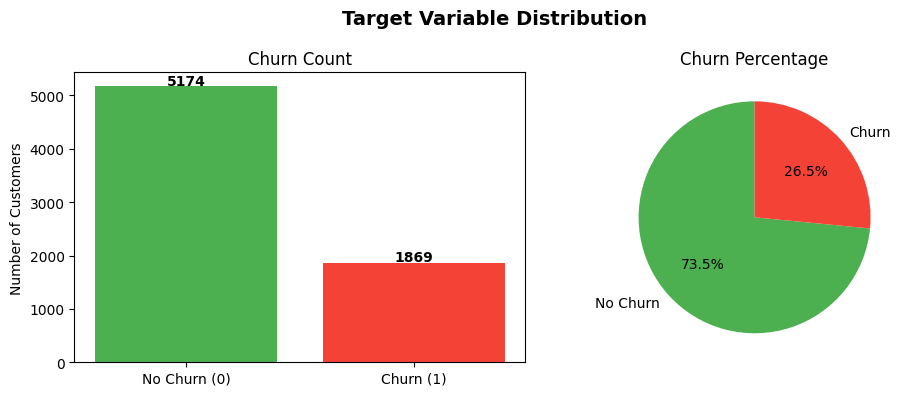

Churn Rate: 26.54%


In [2]:
# Cell 2 — Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Churn Percentage')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Churn Rate: {df['Churn'].mean()*100:.2f}%")

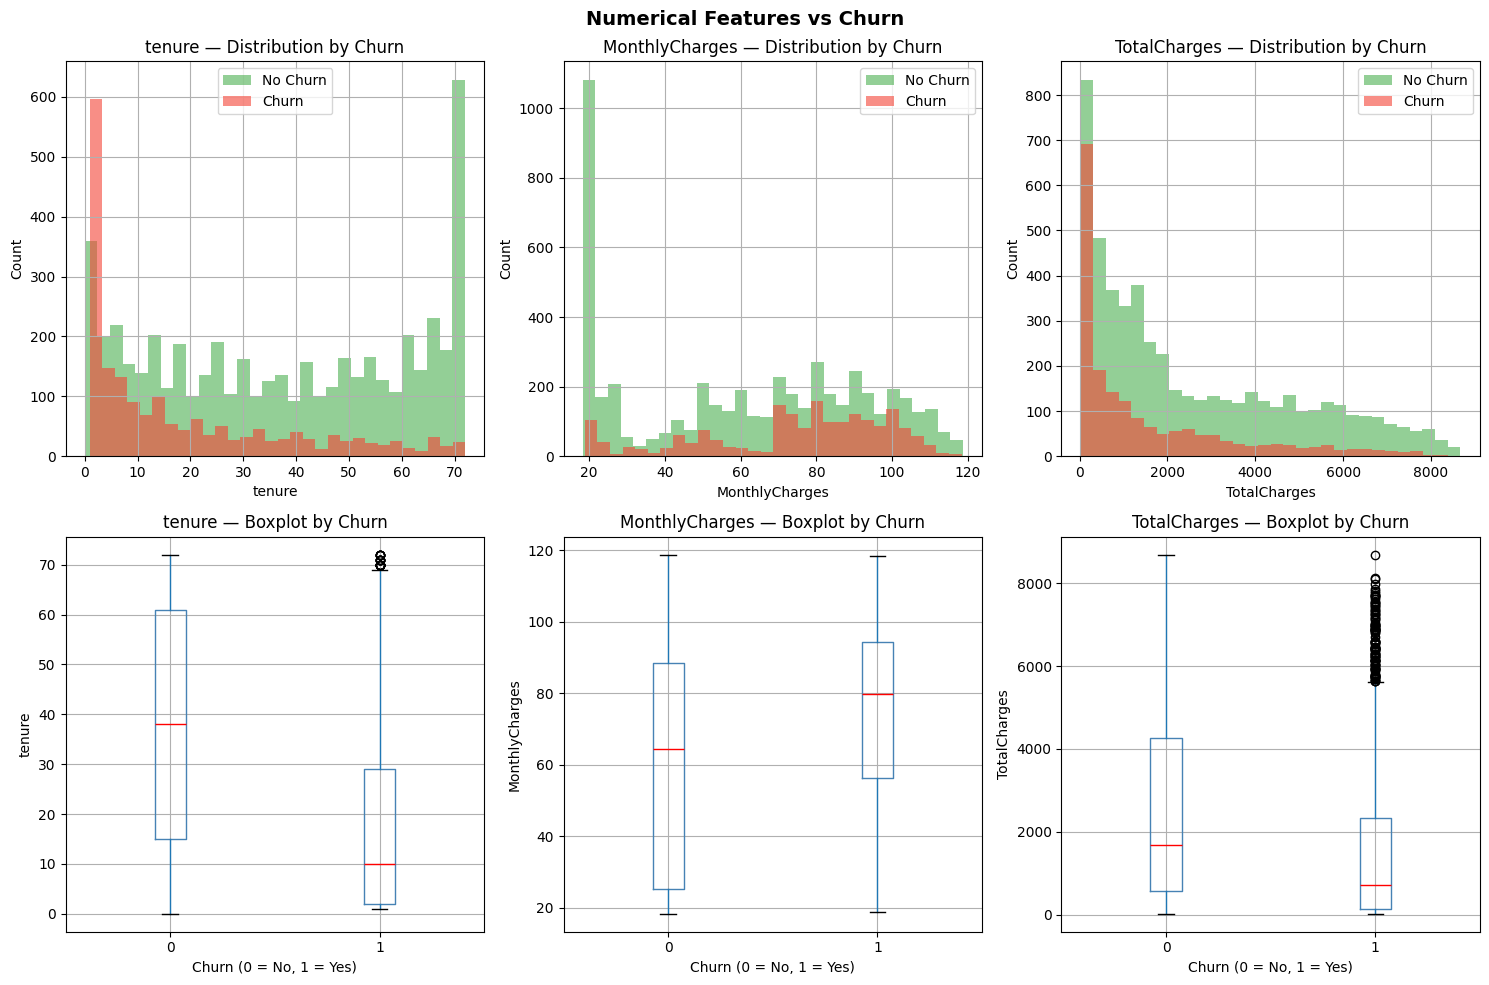

       tenure  MonthlyCharges  TotalCharges
Churn                                      
0       37.57           61.27       2552.88
1       17.98           74.44       1531.80


In [3]:
# Cell 3 — Numerical Features Distribution
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(num_cols):
    # Row 1: Distribution by churn
    df[df['Churn'] == 0][col].hist(bins=30, alpha=0.6, color='#4CAF50', 
                                    label='No Churn', ax=axes[0, i])
    df[df['Churn'] == 1][col].hist(bins=30, alpha=0.6, color='#F44336', 
                                    label='Churn', ax=axes[0, i])
    axes[0, i].set_title(f'{col} — Distribution by Churn')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].legend()

    # Row 2: Boxplot by churn
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    axes[1, i].set_title(f'{col} — Boxplot by Churn')
    axes[1, i].set_xlabel('Churn (0 = No, 1 = Yes)')
    axes[1, i].set_ylabel(col)

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats split by churn
print(df.groupby('Churn')[num_cols].mean().round(2))

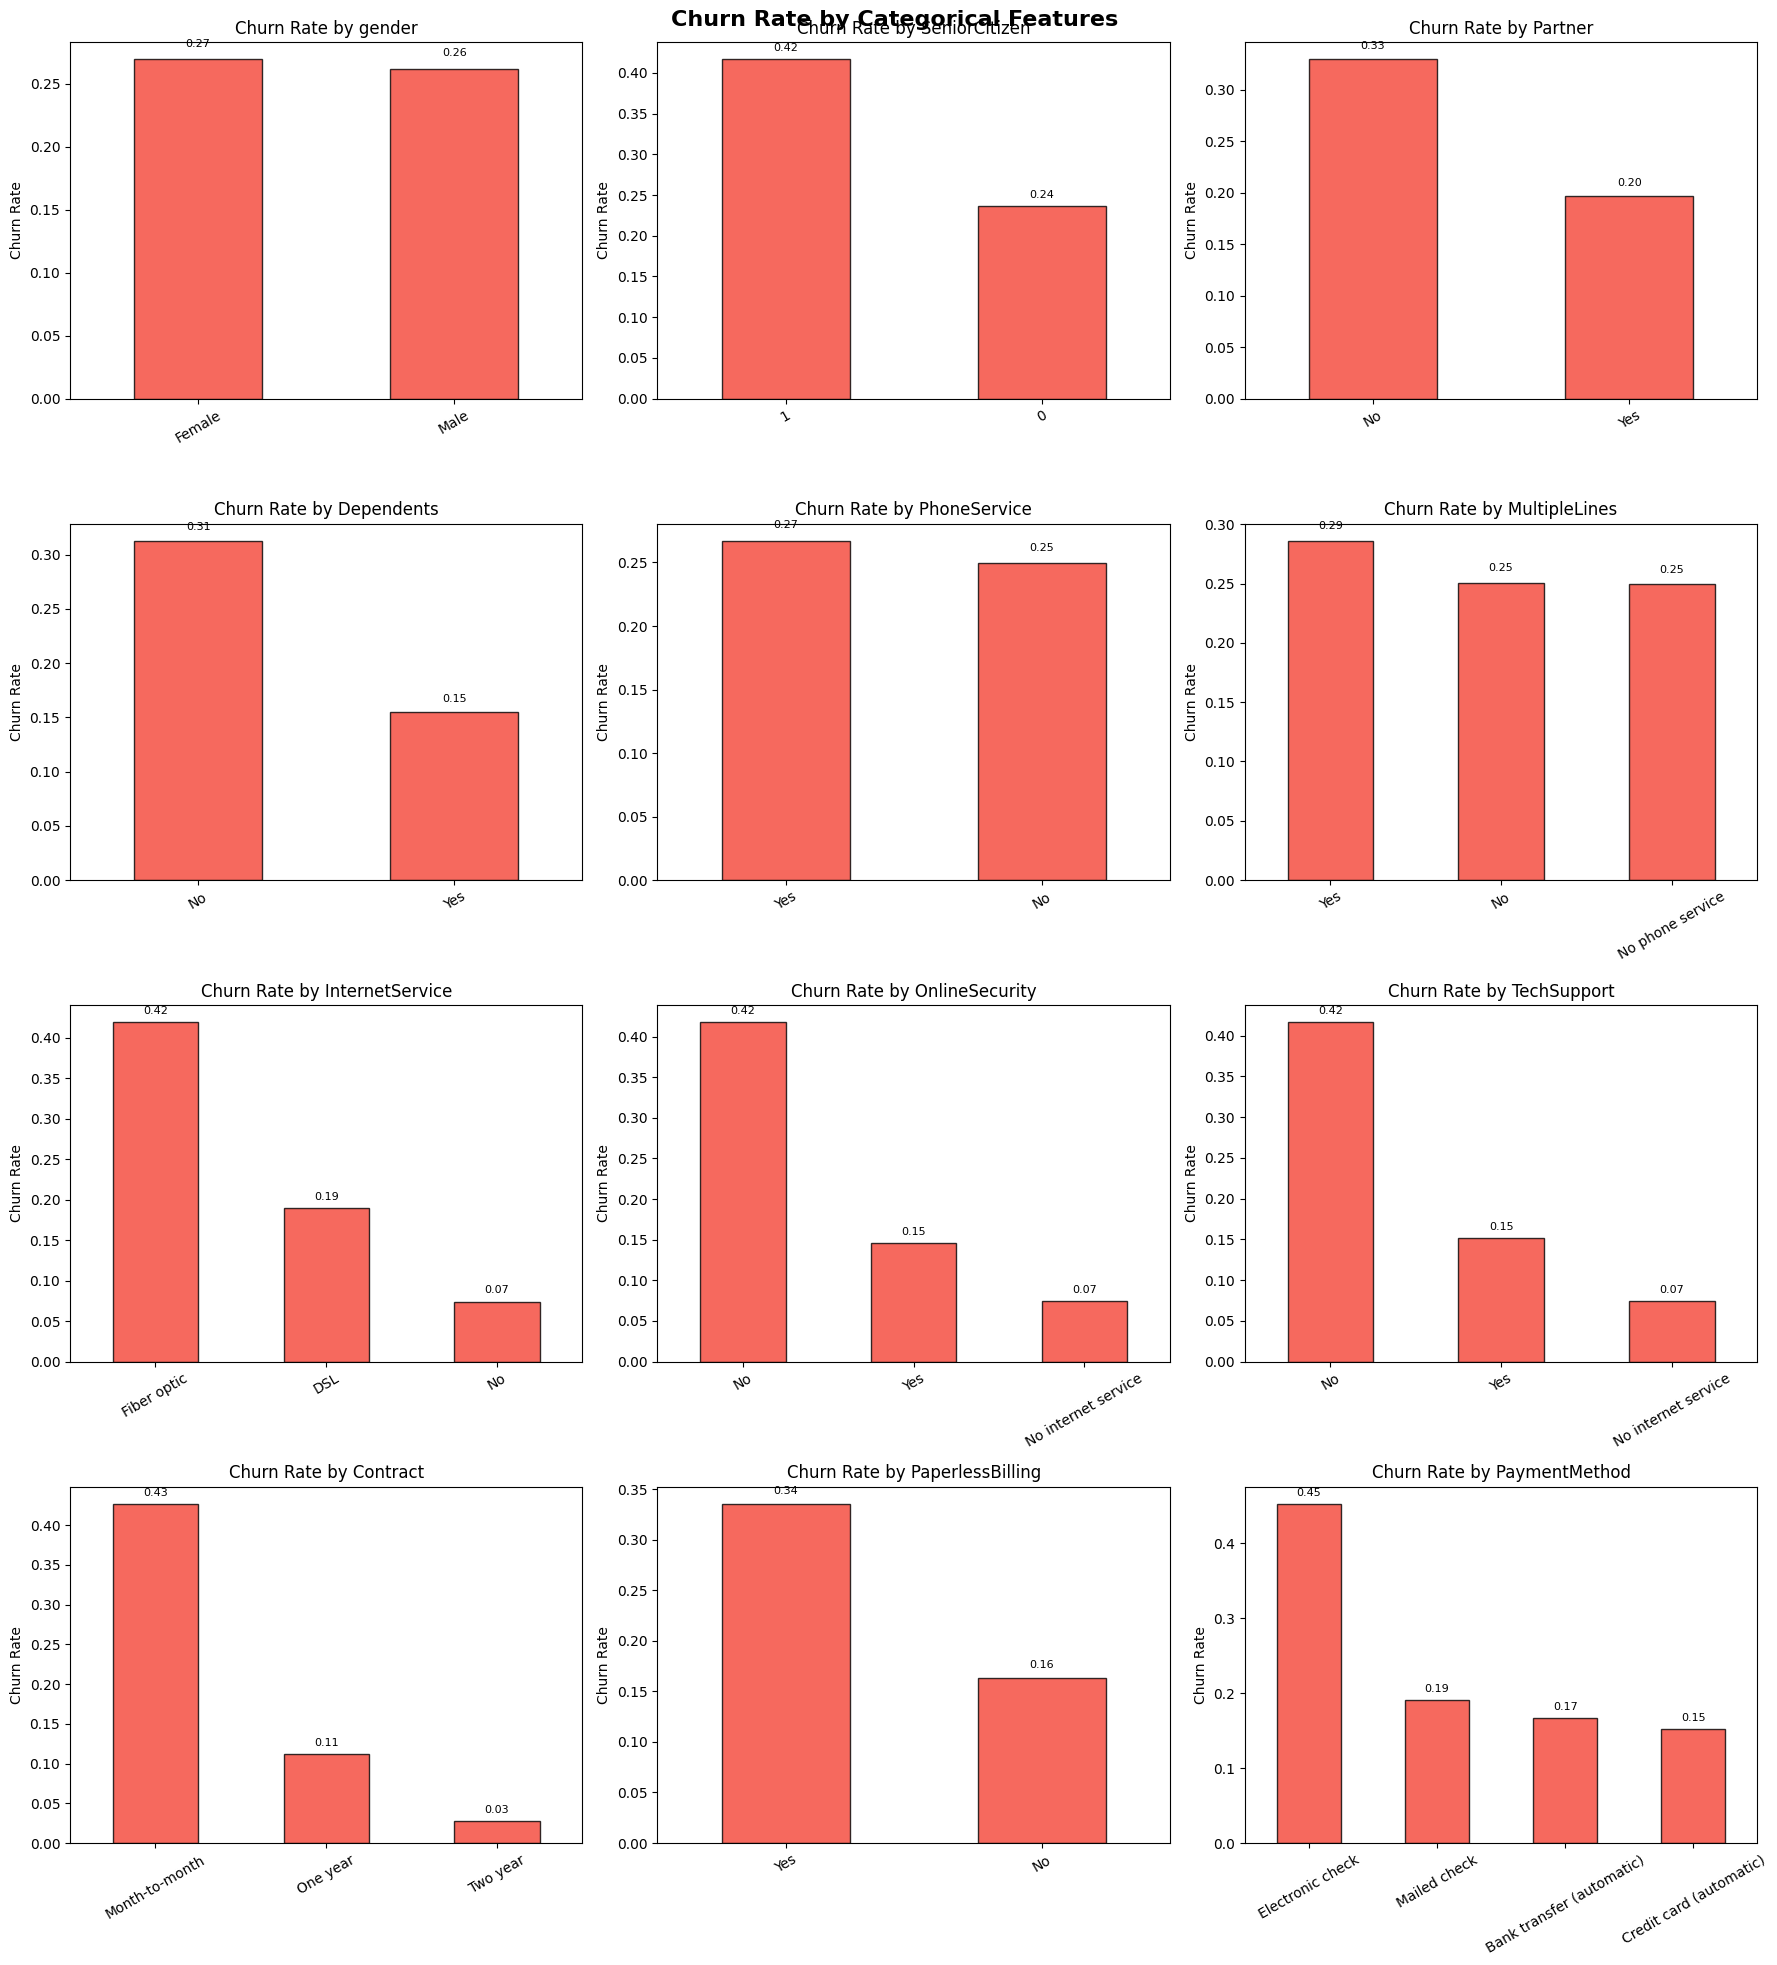

In [4]:
# Cell 4 — Categorical Features vs Churn
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#F44336', alpha=0.8, edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}',
                     ha='center', fontsize=8)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

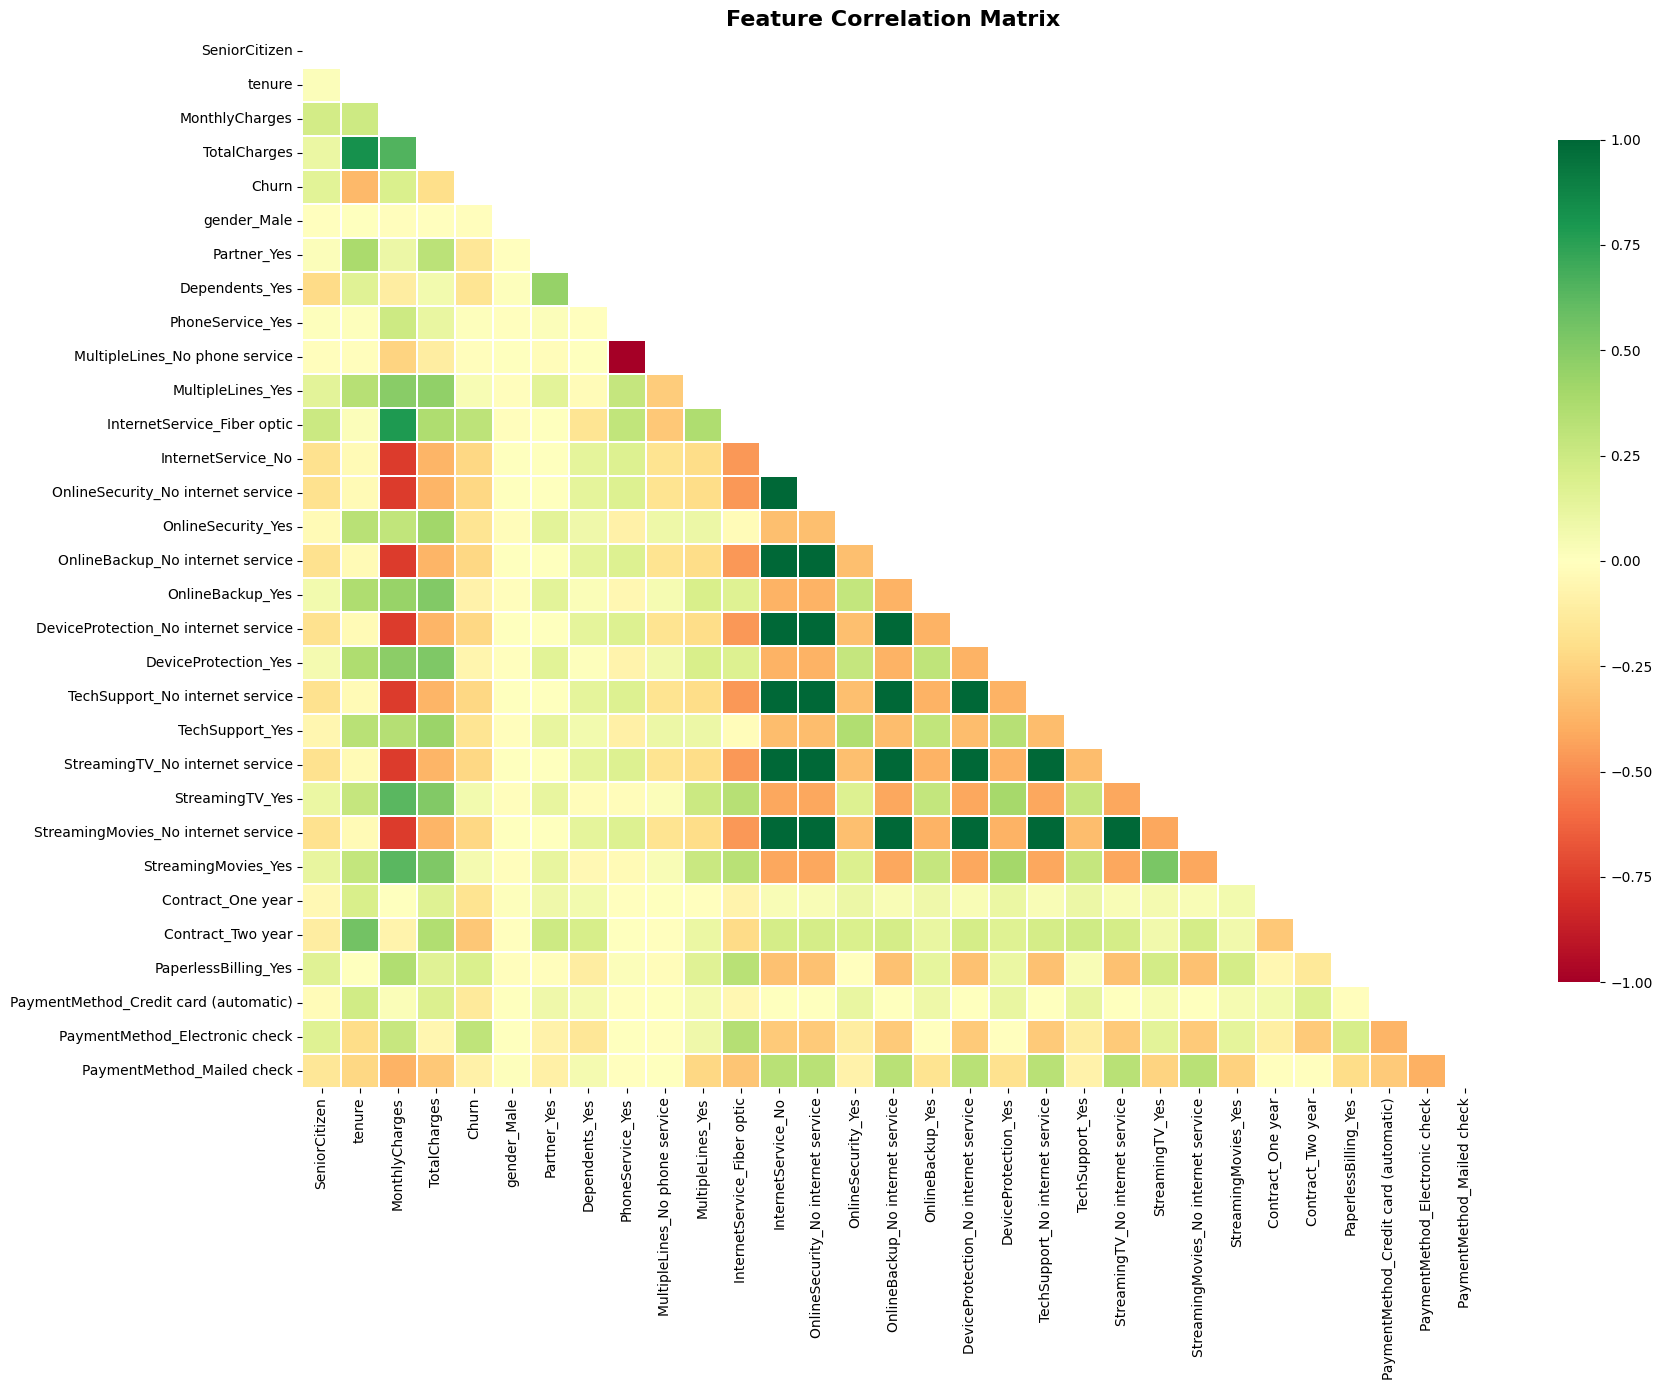

Top 10 features correlated with Churn:

tenure                                 -0.352
InternetService_Fiber optic             0.308
Contract_Two year                      -0.302
PaymentMethod_Electronic check          0.302
StreamingMovies_No internet service    -0.228
TechSupport_No internet service        -0.228
DeviceProtection_No internet service   -0.228
OnlineBackup_No internet service       -0.228
OnlineSecurity_No internet service     -0.228
InternetService_No                     -0.228
Name: Churn, dtype: float64


In [5]:
# Cell 5 — Correlation Heatmap
# Encode categorical columns for correlation analysis
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(18, 14))
corr_matrix = df_encoded.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.3,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Churn specifically
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("Top 10 features correlated with Churn:\n")
print(churn_corr.head(10).round(3))

## 📊 Phase II — EDA Key Findings

### Top Churn Drivers (from correlation analysis)

| Feature | Correlation | Insight |
|---|---|---|
| tenure | -0.352 | Longer customers → less likely to churn |
| InternetService_Fiber optic | +0.308 | Fiber users churn more — possibly pricing |
| Contract_Two year | -0.302 | Long-term contracts strongly reduce churn |
| PaymentMethod_Electronic check | +0.302 | E-check users are high risk |
| TechSupport / OnlineSecurity | -0.228 | Add-on services retain customers |

### Numerical Feature Observations
- **Tenure**: Churners avg 18 months vs 38 months for retained
- **MonthlyCharges**: Churners pay more (₹74 avg vs ₹61)
- **TotalCharges**: Lower for churners due to short tenure

### Class Imbalance
- Churn rate: **26.5%** — handle with SMOTE or `class_weight='balanced'` in Phase III

### Phase III Action Items
- Engineer: `tenure_group`, `charges_per_month_ratio`
- Use top 10 correlated features as priority inputs
- Address 73/27 imbalance before modeling

In [6]:
# Cell 7 — Feature Engineering Preview
df_model = df.copy()

# 1. Tenure groups
df_model['tenure_group'] = pd.cut(df_model['tenure'],
                                   bins=[0, 12, 24, 48, 72],
                                   labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

# 2. Charges per month ratio (TotalCharges / tenure, avoid div by zero)
df_model['charges_per_tenure'] = df_model['TotalCharges'] / (df_model['tenure'] + 1)

# 3. Has add-on services flag
df_model['has_support_services'] = (
    (df_model['TechSupport'] == 'Yes').astype(int) +
    (df_model['OnlineSecurity'] == 'Yes').astype(int) +
    (df_model['OnlineBackup'] == 'Yes').astype(int)
)

# 4. Is high risk payment method
df_model['is_echeque'] = (df_model['PaymentMethod'] == 'Electronic check').astype(int)

print(df_model[['tenure_group', 'charges_per_tenure', 
                 'has_support_services', 'is_echeque']].head(10))
print(f"\nNew shape: {df_model.shape}")

  tenure_group  charges_per_tenure  has_support_services  is_echeque
0        0-1yr           14.925000                     1           1
1        2-4yr           53.985714                     1           0
2        0-1yr           36.050000                     2           0
3        2-4yr           40.016304                     2           0
4        0-1yr           50.550000                     0           1
5        0-1yr           91.166667                     0           1
6        1-2yr           84.756522                     1           0
7        0-1yr           27.445455                     1           0
8        2-4yr          105.036207                     1           1
9        4-6yr           55.364286                     2           0

New shape: (7043, 24)
